In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import os
import umap
import pathlib

/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1779492972.809664    5183 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779492972.895145    5183 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779492975.487126    5183 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floati

In [3]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

pathlib.Path('plots').mkdir(exist_ok=True)
pathlib.Path('results').mkdir(exist_ok=True)

In [4]:
core_path = os.getcwd()   # adjust if needed
orbital_df = pd.read_pickle(os.path.join(core_path, "data/lvl3/", "orbital_df.pkl"))

# Slice to family members only
family_df = orbital_df[orbital_df['is_family_member']].copy().reset_index(drop=True)

print(f"Working dataset : {len(family_df):,} family members")
print(f"Unique families : {family_df['family_1'].nunique()}")

Working dataset : 230,607 family members
Unique families : 98


In [5]:
FEATURES = ['a_p', 'e_p', 'sin_i_p']

X_raw = family_df[FEATURES].values
scaler = RobustScaler()
X = scaler.fit_transform(X_raw)

print(f"Feature matrix shape : {X.shape}")
print(f"Features used        : {FEATURES}")

Feature matrix shape : (230607, 3)
Features used        : ['a_p', 'e_p', 'sin_i_p']


In [6]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,      # local structure — good for tight family clusters
    min_dist=0.05,       # compressed clusters
    metric='euclidean',
    random_state=42,
    verbose=True
)

embedding = reducer.fit_transform(X)
family_df['umap_x'] = embedding[:, 0]
family_df['umap_y'] = embedding[:, 1]

print(f"Embedding shape: {embedding.shape}")

UMAP(min_dist=0.05, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sat May 23 05:06:16 2026 Construct fuzzy simplicial set
Sat May 23 05:06:16 2026 Finding Nearest Neighbors
Sat May 23 05:06:16 2026 Building RP forest with 29 trees


/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sat May 23 05:06:23 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	Stopping threshold met -- exiting after 2 iterations
Sat May 23 05:07:03 2026 Finished Nearest Neighbor Search
Sat May 23 05:07:10 2026 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [02:04]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [02:17]

Sat May 23 05:10:43 2026 Finished embedding
Embedding shape: (230607, 2)


/tmp/ipykernel_5183/4242667900.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap('turbo', len(unique_fams))


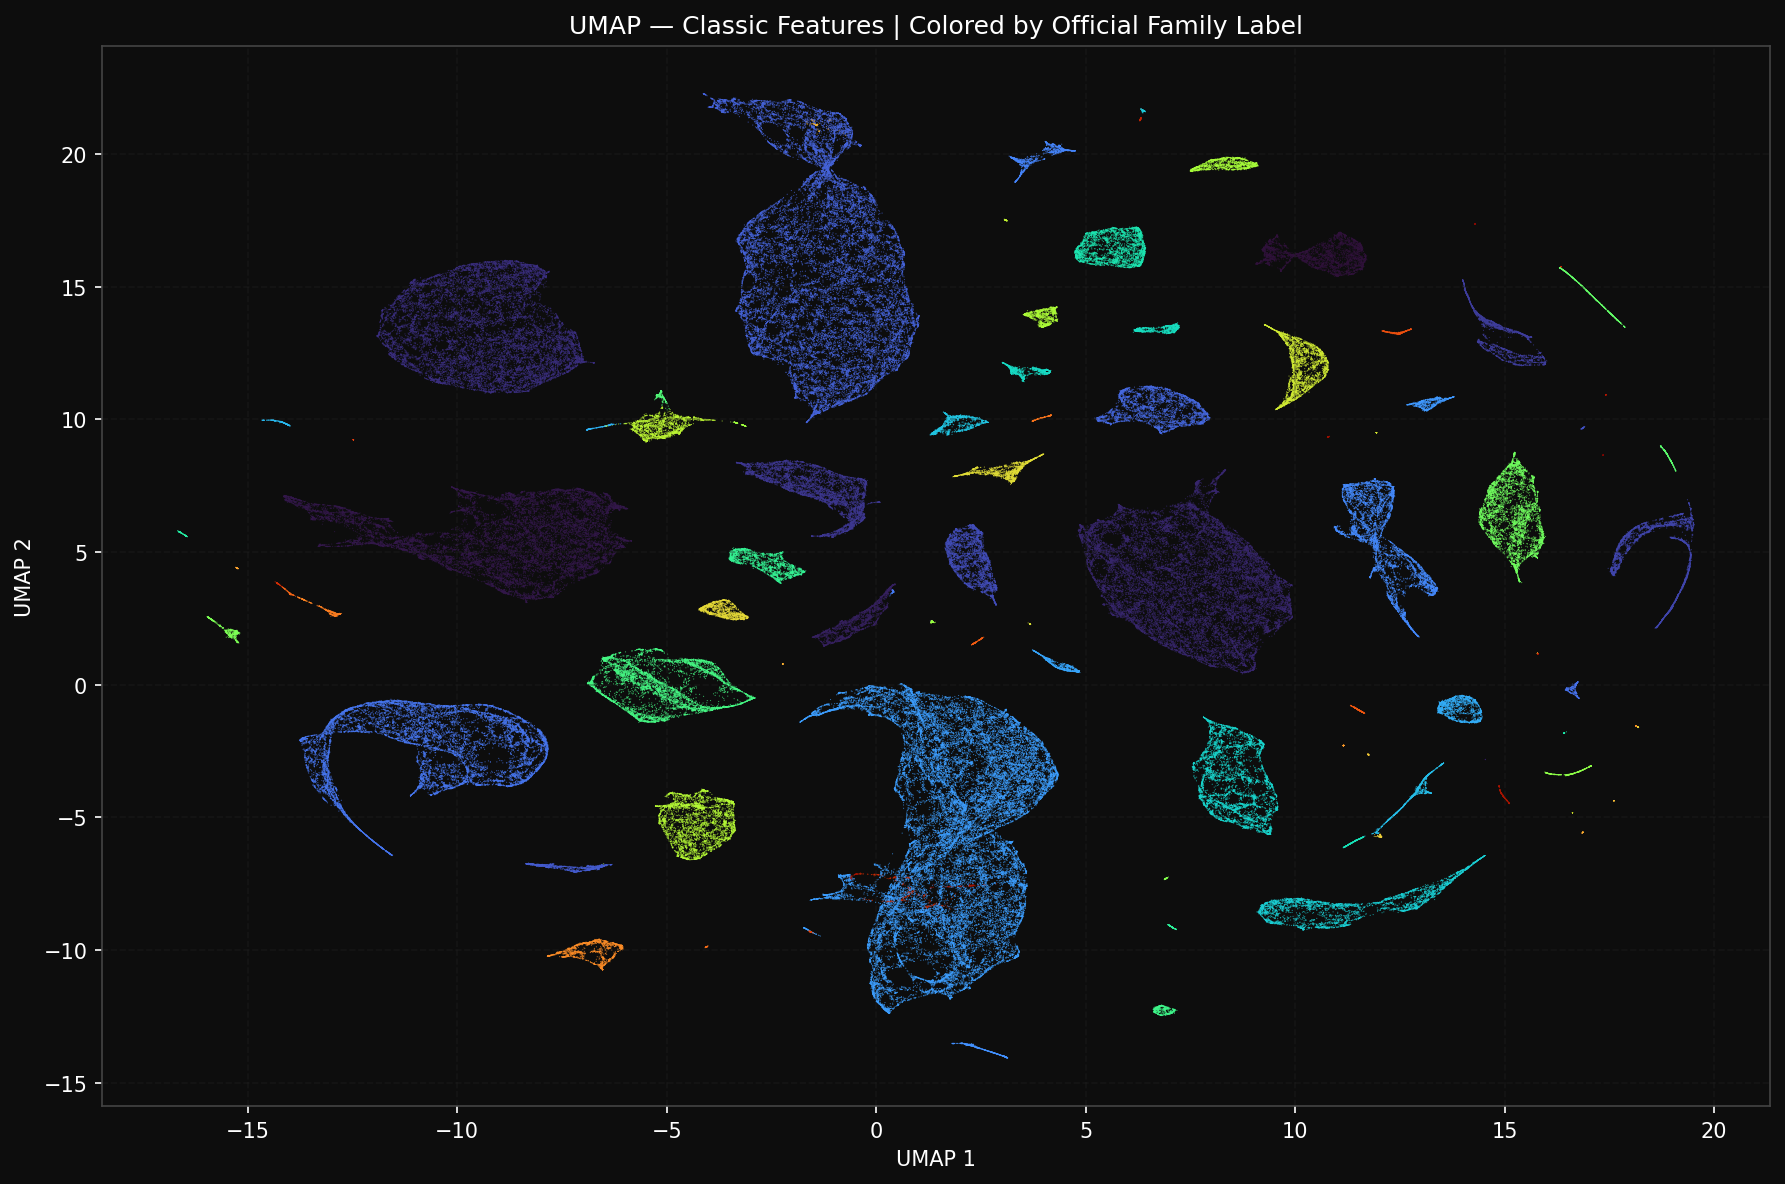

In [15]:
# Build color map for 98 families
unique_fams = family_df['family_1'].unique()
cmap        = plt.cm.get_cmap('turbo', len(unique_fams))
fam_to_color = {f: cmap(i) for i, f in enumerate(unique_fams)}
colors       = family_df['family_1'].map(fam_to_color)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(embedding[:, 0], embedding[:, 1],
           c=colors, s=0.3, alpha=0.7, linewidths=0)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP — Classic Features | Colored by Official Family Label')
ax.grid(True)

plt.tight_layout()
plt.savefig('plots/05a_umap_classic_official.png', dpi=200, bbox_inches='tight')
plt.show()

In [8]:
# Zappalà metric constants
# d² = n²a² [ C1(δa/a)² + C2(δe)² + C3(δsin_i)² ]
# C1=5/4, C2=2, C3=2 for the standard metric
# n = mean motion in rad/yr, a in AU

C1, C2, C3 = 5/4, 2, 2

a  = family_df['a_p'].values
e  = family_df['e_p'].values
si = family_df['sin_i_p'].values
n  = family_df['n'].values   # deg/yr → convert to rad/yr
n_rad = np.deg2rad(n)

# Pairwise differences — this is memory-intensive for 230k objects
# We'll use scipy pdist with a custom metric
print("Computing pairwise velocity distances...")
print("This may take a few minutes for 230k objects...")

def zappala_metric(u, v):
    da  = (u[0] - v[0]) / ((u[0] + v[0]) / 2)   # δa/a
    de  = u[1] - v[1]
    dsi = u[2] - v[2]
    a_mean = (u[0] + v[0]) / 2
    n_mean = (u[3] + v[3]) / 2                    # mean of n_rad
    d2 = (n_mean * a_mean) ** 2 * (C1*da**2 + C2*de**2 + C3*dsi**2)
    return np.sqrt(abs(d2)) * 1731.46             # AU/yr → m/s conversion

# Stack features for pdist
X_hcm = np.column_stack([a, e, si, n_rad])

Computing pairwise velocity distances...
This may take a few minutes for 230k objects...


In [9]:
from sklearn.neighbors import KDTree

D_CUT   = 60    # m/s
hcm_labels = np.full(len(family_df), -1, dtype=int)
cluster_counter = 0

zones = {
    'inner' : (2.0,  2.5),
    'middle': (2.5,  2.95),
    'outer' : (2.95, 3.5),
}

for zone_name, (a_min, a_max) in zones.items():
    mask = (family_df['a_p'] >= a_min) & (family_df['a_p'] < a_max)
    idx  = np.where(mask)[0]
    X_zone = X_hcm[idx]   # [a, e, sin_i, n_rad]

    print(f"\nZone {zone_name}: {len(idx):,} objects")

    # Convert D_CUT from m/s to normalized distance units
    # Use approximate scaling: d_norm ≈ D_CUT / (n_mean * a_mean * 1731.46)
    a_mean    = X_zone[:, 0].mean()
    n_mean    = X_zone[:, 3].mean()
    scale     = n_mean * a_mean * 1731.46
    r_search  = D_CUT / scale

    print(f"  Search radius (normalized): {r_search:.6f}")

    # Build KDTree on scaled proper elements only (a, e, sin_i)
    # Apply Zappalà weights: C1=5/4, C2=2, C3=2
    weights    = np.array([np.sqrt(C1), np.sqrt(C2), np.sqrt(C3)])
    X_weighted = X_zone[:, :3] * weights

    tree = KDTree(X_weighted)

    # Union-Find for single linkage clustering
    parent = np.arange(len(idx))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        px, py = find(x), find(y)
        if px != py:
            parent[px] = py

    print(f"  Running neighbor search & union-find...")
    for i in range(len(idx)):
        neighbors = tree.query_radius([X_weighted[i]], r=r_search)[0]
        for j in neighbors:
            if j != i:
                union(i, j)

    # Assign labels
    root_to_label = {}
    zone_labels   = np.zeros(len(idx), dtype=int)
    for i in range(len(idx)):
        root = find(i)
        if root not in root_to_label:
            root_to_label[root] = cluster_counter
            cluster_counter += 1
        zone_labels[i] = root_to_label[root]

    hcm_labels[idx] = zone_labels
    print(f"  Clusters found: {len(np.unique(zone_labels)):,}")

family_df['hcm_label'] = hcm_labels
print(f"\nTotal HCM clusters : {family_df['hcm_label'].nunique():,}")


Zone inner: 63,107 objects
  Search radius (normalized): 0.008492
  Running neighbor search & union-find...
  Clusters found: 16

Zone middle: 97,467 objects
  Search radius (normalized): 0.009060
  Running neighbor search & union-find...
  Clusters found: 88

Zone outer: 70,033 objects
  Search radius (normalized): 0.009687
  Running neighbor search & union-find...
  Clusters found: 28

Total HCM clusters : 132


In [10]:
ARI = adjusted_rand_score(family_df['family_1'], family_df['hcm_label'])
NMI = normalized_mutual_info_score(family_df['family_1'], family_df['hcm_label'])

print(f"=== HCM Evaluation (Classic Features, d_cut={D_CUT} m/s) ===")
print(f"Adjusted Rand Index (ARI) : {ARI:.4f}   [0=random, 1=perfect]")
print(f"Normalized Mutual Info    : {NMI:.4f}   [0=random, 1=perfect]")
print(f"Official families         : {family_df['family_1'].nunique()}")
print(f"HCM clusters found        : {family_df['hcm_label'].nunique()}")

=== HCM Evaluation (Classic Features, d_cut=60 m/s) ===
Adjusted Rand Index (ARI) : 0.7945   [0=random, 1=perfect]
Normalized Mutual Info    : 0.9446   [0=random, 1=perfect]
Official families         : 98
HCM clusters found        : 132


/tmp/ipykernel_5183/3232814787.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_hcm    = plt.cm.get_cmap('turbo', len(unique_hcm))


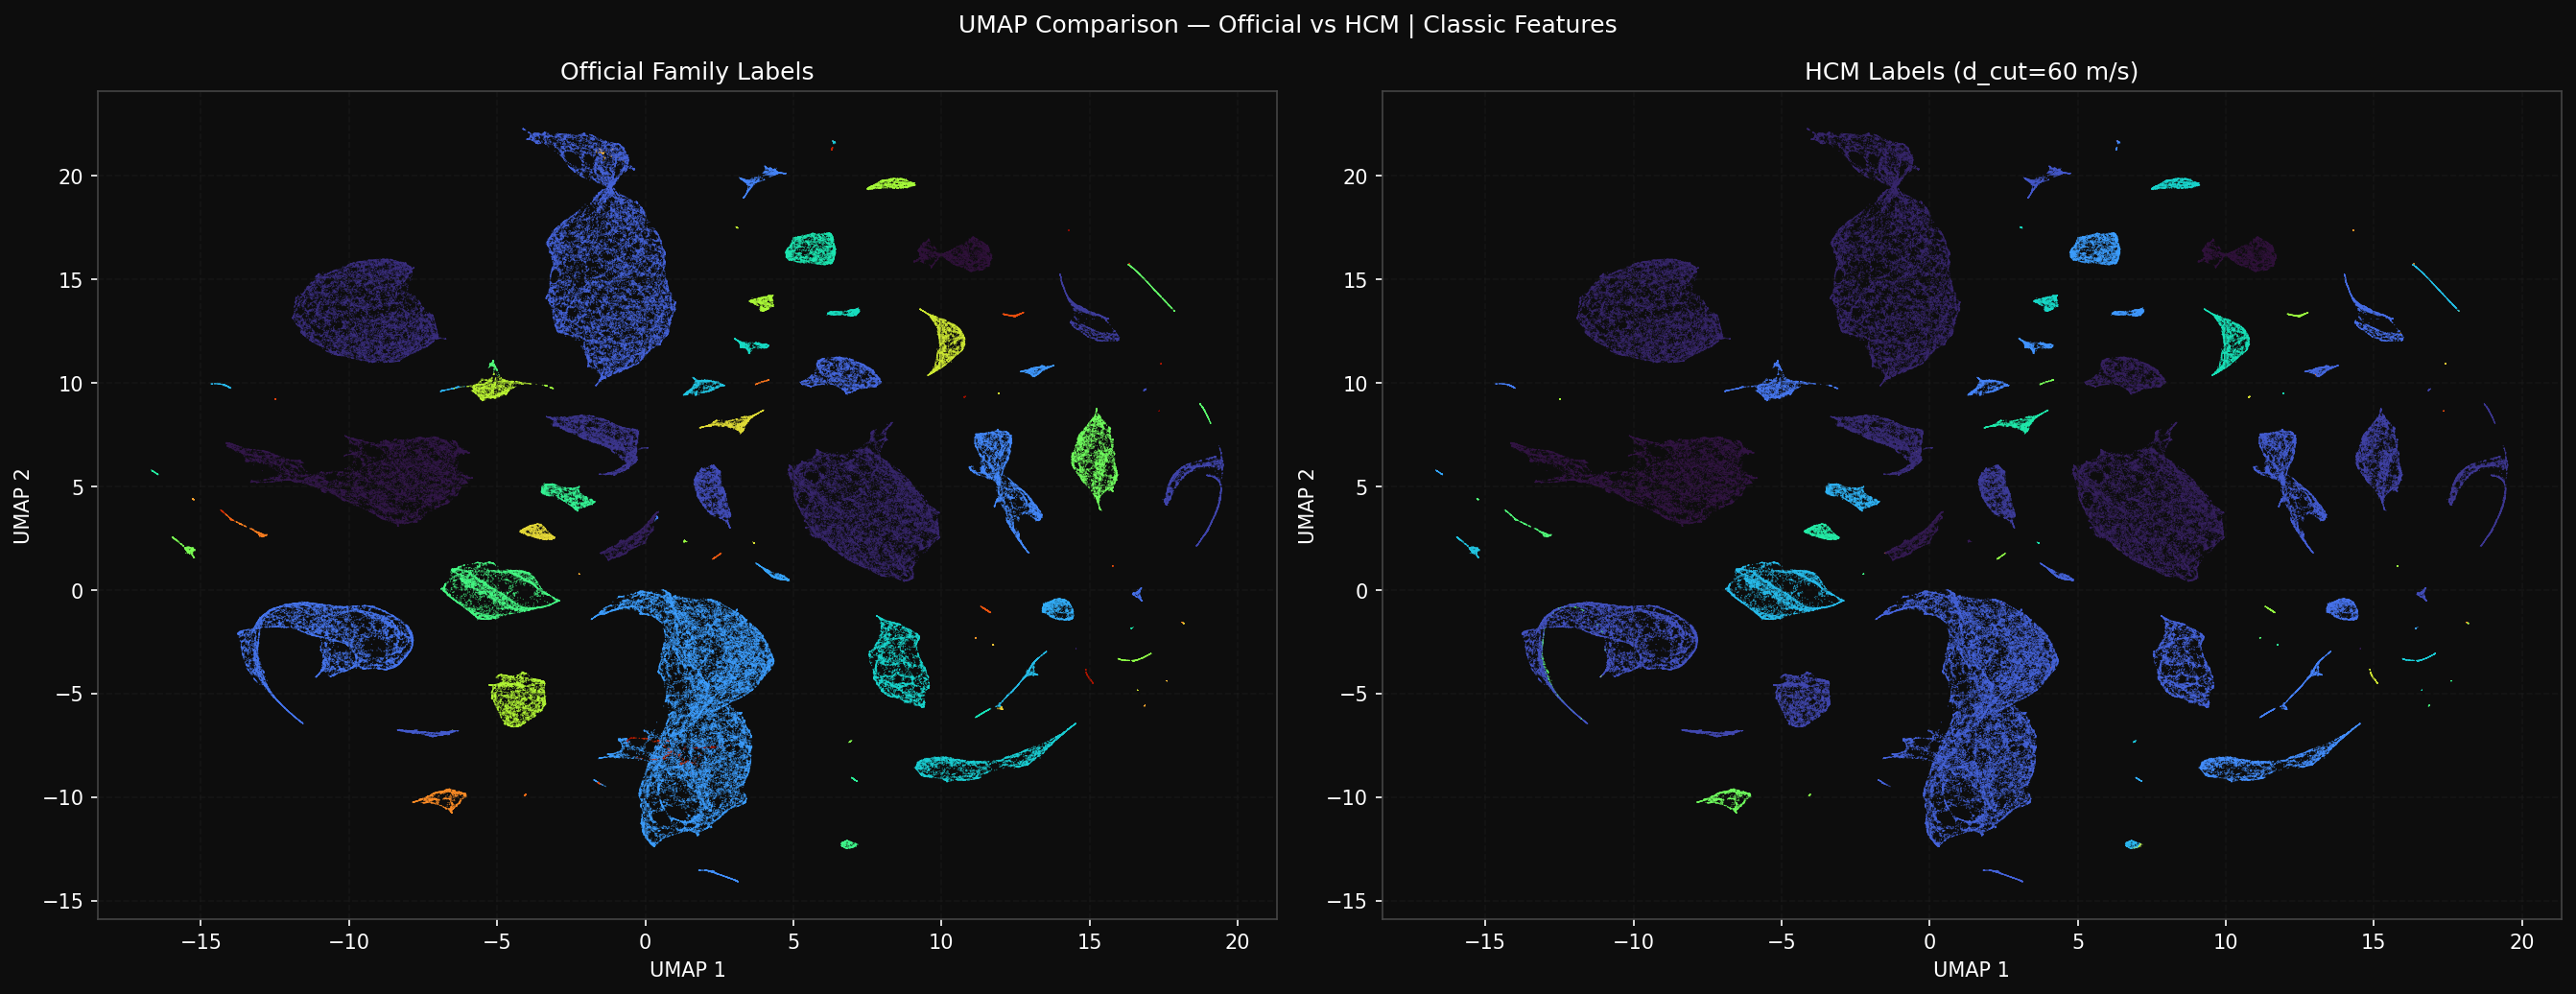

In [16]:
unique_hcm  = family_df['hcm_label'].unique()
cmap_hcm    = plt.cm.get_cmap('turbo', len(unique_hcm))
hcm_to_color = {h: cmap_hcm(i) for i, h in enumerate(unique_hcm)}
colors_hcm   = family_df['hcm_label'].map(hcm_to_color)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, c, title, fname in zip(
    axes,
    [colors, colors_hcm],
    ['Official Family Labels', f'HCM Labels (d_cut={D_CUT} m/s)'],
    ['official', 'hcm']
):
    ax.scatter(embedding[:, 0], embedding[:, 1],
               c=c, s=0.3, alpha=0.7, linewidths=0)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(title)
    ax.grid(True)

plt.suptitle('UMAP Comparison — Official vs HCM | Classic Features', fontsize=12)
plt.tight_layout()
plt.savefig('plots/05a_umap_classic_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [12]:
pathlib.Path(os.path.join(core_path, "data/results")).mkdir(parents=True, exist_ok=True)

family_df[['Asteroid_id', 'family_1', 'hcm_label', 'umap_x', 'umap_y']].to_pickle(
    os.path.join(core_path, 'data/results/05a_hcm_classic_results.pkl')
)